In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import constants as const, units as u

import pyFLD as fld
import simple_eigenstates as se

aR = 4 * const.sigma_sb / const.c
Rgas, mu, gamma, T0 = const.k_B / const.u, 2.353, 1.4, 30 * u.K
E0 = fld.tools.T_to_Er(T0)
time_unit = (const.au / np.sqrt(Rgas / mu * T0)).to('s')

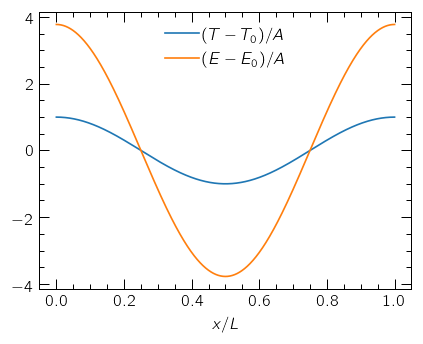

In [2]:
# typical input state with amplitude A = 1e-4
omega, [dT, dE] = se.get_setup_cgs(k0=1, rho_ref=1e-12, output=False)

def to_wave(x, dq):
    return 1e-4 * (dq.real * np.cos(2*np.pi*x) - dq.imag * np.sin(2*np.pi*x))

x = np.linspace(0, 1, 1000)
fig, ax = plt.subplots(figsize=(4,3), dpi=120)

ax.plot(x, 1e4 * to_wave(x, dT) , label=r'$(T-T_0)/A$')
ax.plot(x, 1e4 * to_wave(x, dE) , label=r'$(E-E_0)/A$')
ax.set_xlabel(r'$x/L$')

ax.legend()
plt.show()

In [3]:
def build_disk(rho_ref, kappa, dT, dE):    
    # set up the grid and the default arguments to the solver
    tiny = 1e-4
    ri   = fld.grid.get_domain_with_ghosts(1-tiny, 1+tiny, Nx=1) * u.au
    thi  = fld.grid.get_domain_with_ghosts(np.pi/2-tiny, np.pi/2+tiny, Nx=1)
    phii = fld.grid.get_domain_with_ghosts(0, 1, Nx=1000)
    grid = fld.grid.Grid(ri, thi, phii, geometry='spherical')

    Gas  = fld.fluids.Gas(grid=grid)

    R  = grid.R[grid.act2,grid.act1].to_value('au')
    phi = grid.x3[grid.act3]
    def to_wave(dq):
        x = R[0] * phi[:,None,None]
        return 1e-4 * (dq.real * np.cos(2*np.pi*x) - dq.imag * np.sin(2*np.pi*x))
    
    T0 = 30 * u.K
    E0 = fld.tools.T_to_Er(T0)
    Gas.set_density(np.ones(grid.shape) * fld.tools.toQuantity(rho_ref, u.g / u.cm**3))
    tmp = np.ones(grid.shape) * T0
    tmp[grid.active] += to_wave(dT) * T0
    Gas.set_temperature(tmp)
    Gas.enroll_kappaR(lambda f: fld.tools.toQuantity(kappa, u.cm**2 / u.g))
    Gas.enroll_kappaP(lambda f: fld.tools.toQuantity(kappa, u.cm**2 / u.g))
    Gas.setup()
    
    Disk = fld.FLD.RadiativeEnvironment([Gas], verbose=False, constant_fluxlimiter=True, name='disk')
    bounds = [fld.grid.BOUNDARY_REFLECTIVE] * 6
    vals   = [0] * 6
    Disk.declare_boundaries(bounds, vals)
    
    Disk.Er = np.ones(grid.shape) * E0
    Disk.Er[grid.active] += to_wave(dE) * E0
    Disk.fluids[0].enforce_boundaries(Disk.Er)

    return Disk

In [4]:
from scipy.optimize import curve_fit

def fit_signal(t, T, E):
    qty = 1 * T
    # qty = 1 * E

    def func(x, a, b): return a * np.exp(-b*x)
    def get_fit(x, Qty):
        popt, pcov = curve_fit(func, x, Qty, p0=[1, 1])
        return popt, func(x, *popt)

    Q = 1 * qty

    try:
        popt, fit = get_fit(t, Q)
        damp = popt[1]
    except: damp = np.nan
    
    return damp, [t, Q]

def get_damping_rates(rho_ref=1e-12, kappa=10, dt=1e-2, rtol=1e-8):
    
    omega, [dT, dE] = se.get_setup_cgs(k0=kappa, rho_ref=rho_ref, output=False)
    Disk = build_disk(rho_ref, kappa, dT, dE)
    Disk.configure_solver(rtol=rtol)
    grid = Disk.grid
    phi  = grid.x3[grid.act3]
    idx  = phi.size // 2

    act = grid.active
    T0 = 30 * u.K
    E0 = fld.tools.T_to_Er(T0)
    ts = [0]
    Ts = [Disk.tmp[act][idx,0,0].to_value('K')]
    Es = [Disk.Er[act][idx,0,0].to_value('erg/cm3')]

    tmax = 50
    while ts[-1] < tmax:
        Disk.advance(dt=dt*u.yr)
        ts.append(ts[-1] + dt)
        Ts.append(Disk.tmp[act][idx,0,0].to_value('K'))
        Es.append(Disk.Er[act][idx,0,0].to_value('erg/cm3'))
    
    ts = np.array(ts) * u.yr
    Ts = np.array(Ts) * u.K
    Es = np.array(Es) * u.erg / u.cm**3

    dT = 1e4 * (Ts.to_value(T0) - 1)
    dE = 1e4 * (Es.to_value(E0) - 1)
    damp, _ = fit_signal(ts.to_value(time_unit), dT, dE)
    damp_theo = omega.real.to_value(1/time_unit)
    return damp_theo, damp, (ts, dT, dE)

In [5]:
kappas = np.geomspace(10**-2.5, 10**1.5, 9)

def get_rates_array(rho_ref, dt=1e-1):
    errors = []
    measured   = []
    
    for kappa in kappas:
        print(f'running for kappa = {kappa:.2e}')
        theo, model, _ = get_damping_rates(rho_ref=rho_ref, kappa=kappa, dt=dt)
        errors.append(model/theo - 1)
        measured.append(model)
    
    errors = np.array(errors)
    measured = np.array(measured)
    return measured, errors

omegas_dt01, errors_dt01 = get_rates_array(1e-12, dt=0.1) # < 1 min
omegas_dt02, errors_dt02 = get_rates_array(1e-12, dt=0.01) # ~ 3 mins

kappas_highres = np.geomspace(kappas.min(), kappas.max(), 100)
analytical = np.array([se.get_setup_cgs(k0=k0, rho_ref=1e-12)[0].real.to_value(1/time_unit) for k0 in kappas_highres])

running for kappa = 3.16e-03
running for kappa = 1.00e-02
running for kappa = 3.16e-02
running for kappa = 1.00e-01
running for kappa = 3.16e-01
running for kappa = 1.00e+00
running for kappa = 3.16e+00
running for kappa = 1.00e+01
running for kappa = 3.16e+01
running for kappa = 3.16e-03
running for kappa = 1.00e-02
running for kappa = 3.16e-02
running for kappa = 1.00e-01
running for kappa = 3.16e-01
running for kappa = 1.00e+00
running for kappa = 3.16e+00
running for kappa = 1.00e+01
running for kappa = 3.16e+01


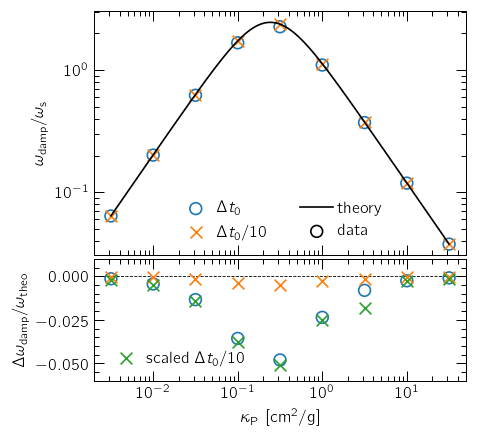

In [6]:
fig, ax = plt.subplots(nrows=2, dpi=120, figsize=(4, 4), gridspec_kw=dict(height_ratios=[2,1]))
fig.subplots_adjust(hspace=0.02)

L = 1 * u.au
k = 2 * np.pi / L
lam = 2 * np.pi / k
cV = Rgas / mu / (gamma-1)

omega_s = (k * np.sqrt(Rgas * T0 / mu)).to_value(1/time_unit)

ax[0].plot(kappas_highres, analytical / omega_s, '-', lw=1, c='k')
ax[0].scatter(kappas, omegas_dt01 / omega_s, marker='o', facecolor='none', edgecolor='C0', s=50, label=r'$\Delta t_0$')
ax[1].scatter(kappas, errors_dt01, marker='o', facecolor='none', edgecolor='C0', s=50)

ax[0].scatter(kappas, omegas_dt02 / omega_s, marker='x', c='C1', s=50, label=r'$\Delta t_0/10$')
ax[1].scatter(kappas, errors_dt02, marker='x', c='C1', s=50)
ax[1].scatter(kappas, errors_dt02*10, marker='x', c='C2', s=50, label=r'scaled $\Delta t_0/10$')

for axis in ax: axis.set_xscale('log')
ax[0].set_xticklabels([])
ax[1].legend()

ax[0].set_yscale('log')
ax[0].set_ylabel(r'$\omega_\text{damp} / \omega_\text{s}$')
ax[1].set_ylabel(r'$\Delta\omega_\text{damp} / \omega_\text{theo}$')
# ax[-1].set_xlabel(r'$\tau = \kappa_\text{P}\rho_0 L$')
ax[-1].set_xlabel(r'$\kappa_\text{P}$ [cm${}^2$/g]')
ax[1].set_ylim(-0.06, 0.01)

ax[0].plot(np.nan, np.nan, ls='-', c='k', label='theory')
ax[0].scatter(np.nan, np.nan, facecolor='none', edgecolor='k', s=50, label='data')
ax[0].legend(ncols=2)
ax[1].axhline(0, ls='--', c='k', lw=0.5, zorder=0)

plt.show()

In [7]:
# since the solver is first-order accurate in time, the errors also scale linearly with Δt.
# You can see that by multiplying by 10 the amplitude of the errors in the run with Δt=0.01,
# we roughly get the same behavior as in the original Δt=0.1.